# Library Import

In [5]:
import gymnasium as gym
import torch
from torch import nn
import torch.optim as optim
from torch.distributions import Normal      # normal dist

import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, stdev
import random

import re, os, json, time
from datetime import datetime
from collections import deque
from tqdm import tqdm

# --- import the custom-made TD3 algorithm
import sys
sys.path.insert(0,'..')
from algos import TD3

# HalfCheetah Training

In [ ]:
model_registry = {
    'TD3_v0': {
        'actor_config': [128,128,128],
        'critic_config': [128,128,128]
    },
    'TD3_v1': {
        'actor_config': [256, 256],
        'critic_config': [256, 256]
    },
    'TD3_v2': {
        'actor_config': [256, 256, 256],
        'critic_config': [256, 256, 256]
    },
    'TD3_v3': {
        'actor_config': [256, 256, 256, 256],
        'critic_config': [256, 256, 256, 256]
    },
    'TD3_v4': {
        'actor_config': [400, 300],
        'critic_config': [400, 300]
    },
    'TD3_v5': {
        'actor_config': [512, 256],
        'critic_config': [512, 256]
    }
}

MODEL_NAME = 'TD3_v4'
ALPHA1 = 5e-4
ALPHA2 = 5e-4
BETA = 5e-4
GAMMA = 0.99
TAU_C = 5e-3
TAU_A = 5e-3
SIGMA = 0.1
CLIP = 0.2

BUFFER_SIZE = 200_000
BUFFER_INIT = 10_000
BATCH_SIZE = 256
  
UPDATE_FREQ = 2
UPDATE_STEP = 2
TRAIN_ITER = 1_000_000
TRAIN_CRIT = {"pass_limit": 1, "pass_score": 7_000, 'coeff_var_limit': 1.0}
RESULT_FOLDER = 'halfcheetah_TD3_results'
CUDA_ENABLED = True
EARLY_STOP = True

run_00009: 100%|█████████████████████████████████████████| 1000000/1000000 [55:55<00:00, 297.98it/s]


Training ended with no good model found :<
Best model episode 0


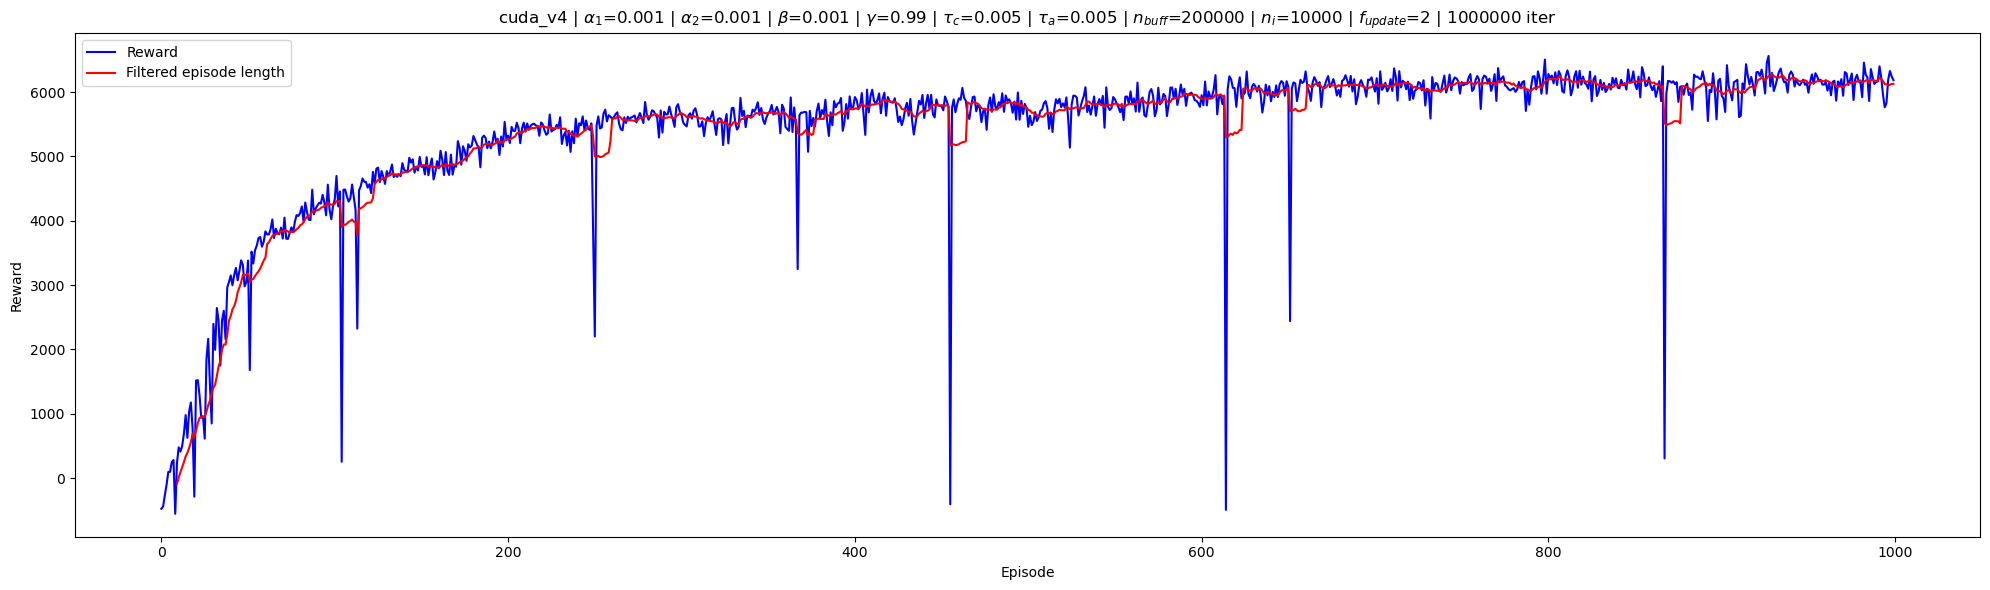

In [7]:
env = gym.make("HalfCheetah-v5",
               forward_reward_weight=1,     # weighting factor of the moving forward reward
               ctrl_cost_weight=0.1,        # weighting factor of the large action penalty
               reset_noise_scale=0.1,       # scale of random pertubations in the initial state
               exclude_current_positions_from_observation=True
               )

for i in range(1):    
    seed = np.random.randint(1,100)
    TD3_experiment = TD3(model_name = MODEL_NAME, model_registry=model_registry, env=env,
                     alpha1=ALPHA1,alpha2=ALPHA2,beta=BETA,gamma=GAMMA,
                     tau_c=TAU_C,tau_a=TAU_A,sigma=SIGMA,clip=CLIP,
                     buffer_size=BUFFER_SIZE,buffer_init=BUFFER_INIT, batch_size=BATCH_SIZE, 
                     update_f=UPDATE_FREQ, update_step=UPDATE_STEP, iter=TRAIN_ITER,
                     seed=seed,
                     train_crit=TRAIN_CRIT,
                     result_folder=RESULT_FOLDER,
                     cuda_enabled=CUDA_ENABLED)                 
    TD3_experiment.train(early_stop=EARLY_STOP,verbose=True)

In [8]:
reward_hist = TD3_experiment.reward_hist

In [9]:
reward_hist

[np.float64(-478.1033657498803),
 np.float64(-440.71517127258824),
 np.float64(-266.0593746401083),
 np.float64(-103.00267358308344),
 np.float64(95.36193574484993),
 np.float64(94.78074152821415),
 np.float64(247.5081309449474),
 np.float64(279.92676211038133),
 np.float64(-557.0460310747754),
 np.float64(239.2595574056255),
 np.float64(476.6777063149974),
 np.float64(410.723018238005),
 np.float64(499.31556451766926),
 np.float64(689.5352198989974),
 np.float64(977.9285146409397),
 np.float64(624.7652125437262),
 np.float64(1031.387941135788),
 np.float64(1175.0827720404845),
 np.float64(766.218697030085),
 np.float64(-290.1772409090579),
 np.float64(1514.1758051959196),
 np.float64(1522.4525799252958),
 np.float64(1289.5641505112187),
 np.float64(936.2135802904694),
 np.float64(959.7559388288353),
 np.float64(611.7377010938053),
 np.float64(1847.3457455440707),
 np.float64(2164.1128011659657),
 np.float64(1461.258396900447),
 np.float64(847.631942248862),
 np.float64(2396.8001845846